<a href="https://colab.research.google.com/github/Justine-Lewis/carisurg_portfolio/blob/main/notebooks/Week6_Interim_BaselineModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#WEEK 6 INTERIM DELIVERABLE

##Implementing Logistic Regression & Decision Tree
- Training two baseline triage models cleanly and reproducibly.

- Audience: Caribbean Clinical-AI trainees · Mercer General Hospital · dataset: Yale EMMLC (cleaned)

###Justine Lewis
*July 10, 2026*

------------------------------------------------------------
##0. WEEK 5 CLEANING PIPELINE FOR WEEK 6 MODELLING
------------------------------------------------------------
This follows the Week 5 Tutorial 3 cleaning approach.
The goal is to create a modelling-ready dataset before training
the Week 6 baseline classifiers.
 This was acciedentally left out of my week 5 notebook (sorry!)


In [23]:
#importing essential libraries
import numpy as np                 # numerical helpers (NaN, medians, etc.)
import pandas as pd                # tables / DataFrames — our main tool
import matplotlib.pyplot as plt    # plotting

# Let pandas show more of a wide table when we print it:
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

print("Environment ready · pandas", pd.__version__)

Environment ready · pandas 2.2.2


In [24]:
from pathlib import Path

# Define project paths
DATA_PATH = Path("yaleemmlc_admissionprediction_triage.csv")
DOCS_PATH = Path("../docs")
DATA_DIR = Path("../data")

DOCS_PATH.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

# Load the raw Week 5 triage dataset
df = pd.read_csv(DATA_PATH)

print("Raw dataset shape:", df.shape)
print("Total missing values:", df.isna().sum().sum())
print("Columns with missing values:", (df.isna().sum() > 0).sum())

Raw dataset shape: (55121, 226)
Total missing values: 0
Columns with missing values: 0


In [25]:
#Defining the target, TARGET = "esi".
TARGET = "esi"

PLAUSIBLE = {
    "triage_vital_hr": (20, 250),
    "triage_vital_sbp": (50, 300),
    "triage_vital_dbp": (30, 200),
    "triage_vital_rr": (5, 80),
    "triage_vital_o2": (50, 100),
    "triage_vital_temp": (90, 110),   # Fahrenheit
    "triage_glucose": (20, 1000)
}

def classify_columns(df):
    """Group dataset columns into clinically meaningful families."""
    return {
        "vitals": [
            col for col in df.columns
            if col.startswith("triage_vital_") or col == "triage_glucose"
        ],
        "chief_complaints": [
            col for col in df.columns
            if col.startswith("cc_")
        ],
        "demographics": [
            col for col in [
                "age", "gender", "ethnicity", "race", "lang",
                "religion", "maritalstatus", "employstatus",
                "insurance_status"
            ]
            if col in df.columns
        ],
        "admin": [
            col for col in [
                "dep_name", "arrivalmode", "arrivalmonth",
                "arrivalday", "arrivalhour_bin"
            ]
            if col in df.columns
        ],
        "leakage": [
            col for col in [
                "disposition", "previousdispo"
            ]
            if col in df.columns
        ]
    }


def clean_triage(raw):
    """
    Week 5 cleaning pipeline.

    Takes the raw triage DataFrame and returns a cleaned copy
    suitable for Week 6 baseline modelling.
    """
    d = raw.copy()

    # Remove accidental index columns created during CSV export.
    unnamed_cols = [col for col in d.columns if col.startswith("Unnamed")]
    if unnamed_cols:
        d = d.drop(columns=unnamed_cols)

    fam = classify_columns(d)

    # 1. Drop rows with no triage label.
    # We cannot train a supervised model on rows with no recorded target.
    d = d[d[TARGET].notna()].copy()

    # 2. Make vital-sign columns and age numeric.
    # Any stray text becomes NaN and can then be handled consistently.
    numeric_cols = list(fam["vitals"])
    if "age" in d.columns:
        numeric_cols.append("age")

    for col in numeric_cols:
        d[col] = pd.to_numeric(d[col], errors="coerce")

    # 3. Flag physiologically implausible values as missing.
    # These are not capped because extreme invalid values should not be treated as real.
    for col, (low, high) in PLAUSIBLE.items():
        if col in d.columns:
            out_of_range = (d[col] < low) | (d[col] > high)
            d.loc[out_of_range, col] = np.nan

    # 4. Fill vital-sign gaps using the median.
    # The median is robust to extreme values.
    for col in fam["vitals"]:
        d[col] = d[col].fillna(d[col].median())

    # 5. Fill oxygen-device and chief-complaint flags with 0.
    # Blank flag fields are treated as "not recorded/present".
    if "triage_vital_o2_device" in d.columns:
        d["triage_vital_o2_device"] = d["triage_vital_o2_device"].fillna(0)

    for col in fam["chief_complaints"]:
        d[col] = d[col].fillna(0)

    # 6. Fill text categories with "Unknown".
    # This keeps rows rather than silently dropping patients with incomplete labels.
    for col in fam["demographics"] + fam["admin"] + fam["leakage"]:
        if col in d.columns and d[col].dtype == object:
            d[col] = d[col].fillna("Unknown")

    # 7. Convert target to whole-number ESI class.
    d[TARGET] = d[TARGET].round().astype(int)

    # Keep only valid ESI classes 1-5.
    d = d[d[TARGET].between(1, 5)].copy()

    return d


In [26]:
# Apply the cleaning pipeline
df_clean = clean_triage(df)

print("Raw shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Missing values after cleaning:", df_clean.isna().sum().sum())
print("ESI classes after cleaning:")
print(df_clean[TARGET].value_counts().sort_index())

Raw shape: (55121, 226)
Cleaned shape: (55121, 225)
Missing values after cleaning: 0
ESI classes after cleaning:
esi
1       77
2    17924
3    27010
4     8896
5     1214
Name: count, dtype: int64


In [27]:
# Save cleaned dataset for Week 6 modelling
CLEAN_DATA_PATH = Path("triage_cleaned_v1.csv")
df_clean.to_csv(CLEAN_DATA_PATH, index=False)

print("Saved cleaned dataset to:", CLEAN_DATA_PATH)

Saved cleaned dataset to: triage_cleaned_v1.csv


#1. Loading Cleaned Week 5 Data: Week 6 setup

##Importing the model libraries and random seed
*The random seed is fixed so the train/test split and baseline results are reproducible.*

In [28]:
# This cell imports the modelling and evaluation tools needed for the
# Week 6 interim baseline model deliverable.

'''
scikit-learn (sklearn): the machine-learning toolkit
joblib: saves a trained model to a file so we can reuse it later
'''
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    recall_score,
)


#Initializing a constant random seed for reproducibility.
RANDOM_SEED = 42


print(" Week 6 modelling libraries loaded.")
print(" Random seed:", RANDOM_SEED)


 Week 6 modelling libraries loaded.
 Random seed: 42


#2. Define Target, Feature and exclude leakage columns

The target is `esi`, the triage level assigned to the patient. Columns such as `disposition` and `previousdispo` are excluded because they are known after the visit or after earlier disposition decisions, so using them would allow the model to peek at information not available at triage time.

In [29]:
# ------------------------------------------------------------
# TARGET AND FEATURE DEFINITIONS
# ------------------------------------------------------------
# Target: ESI triage level. Lower ESI values usually indicate higher acuity.
TARGET = "esi"

#Columns known only after triage or after the visit are excluded to avoid leakage.
LEAKAGE = ["disposition", "previousdispo"]

#Administrative/context columns are excluded for this baseline because the
#interim target is a simple clinically interpretable baseline, not a full model.
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]

DEMOGRAPHICS = [
    "age", "gender", "ethnicity", "race", "lang", "religion",
    "maritalstatus", "employstatus", "insurance_status"
]


#Index-like columns should not be used as predictors.
ID_OR_INDEX = ["Unnamed: 0"]

#Drop rows with missing target values, if any.
#Use df_clean because it has already gone through the Week 5 cleaning pipeline.
model_df = df_clean.dropna(subset=[TARGET]).copy()

# Convert ESI from float to integer labels when appropriate.
# This makes the class labels display cleanly as 1, 2, 3, 4, 5.
model_df[TARGET] = model_df[TARGET].astype(int)

# Candidate predictors start as all non-target columns minus excluded groups.
excluded_cols = set([TARGET] + LEAKAGE + ADMIN + DEMOGRAPHICS + ID_OR_INDEX)
candidate_features = [col for col in model_df.columns if col not in excluded_cols]

# Keep numeric features only for this first baseline.
# This avoids one-hot encoding at the interim stage and keeps the pipeline simple.
numeric_features = model_df[candidate_features].select_dtypes(include=[np.number]).columns.tolist()

X = model_df[numeric_features].copy()
y = model_df[TARGET].copy()

# Fill any remaining numeric gaps with the training-column median later.
# The Week 5 full dataset had 0 missing values, but this keeps the model robust.


print("Rows available for modelling:", model_df.shape[0])
print("Target:", TARGET)
print("Number of numeric model features:", len(numeric_features))
print("Excluded leakage columns:", [c for c in LEAKAGE if c in df.columns])
print("First 10 model features:", numeric_features[:10])
print("ESI class counts:")
print(y.value_counts().sort_index())

Rows available for modelling: 55121
Target: esi
Number of numeric model features: 208
Excluded leakage columns: ['disposition', 'previousdispo']
First 10 model features: ['triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2', 'triage_vital_o2_device', 'triage_vital_temp', 'triage_glucose', 'cc_abdominalcramping', 'cc_abdominaldistention']
ESI class counts:
esi
1       77
2    17924
3    27010
4     8896
5     1214
Name: count, dtype: int64


## 3. Train/test split: 80/20 stratified on ESI

A stratified split keeps the ESI class balance similar in the training and testing sets. This matters because ESI 1 patients are usually rare, and a non-stratified split could accidentally place too few critical patients in the test set.

In [30]:
'''80% of the data is used for training, and 20% is held out for testing.
stratify=y preserves the ESI distribution in both sets.'''
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_SEED,
)


print("Training patients:", X_train.shape[0])
print("Testing patients:", X_test.shape[0])

#check that the stratified split preserved the ESI class distribution
print("Training ESI distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print("\nTesting ESI distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(3))

Training patients: 44096
Testing patients: 11025
Training ESI distribution:
esi
1    0.001
2    0.325
3    0.490
4    0.161
5    0.022
Name: proportion, dtype: float64

Testing ESI distribution:
esi
1    0.001
2    0.325
3    0.490
4    0.161
5    0.022
Name: proportion, dtype: float64


## 4. Baseline to beat: stratified random dummy model

The dummy model does not learn clinical patterns. It guesses while preserving the class distribution. The logistic regression and decision tree should perform better than this baseline to be worth taking forward.

In [31]:
'''
This model is the floor: it guesses ESI labels according to the training
distribution. A real model should beat this on clinically important metrics.
'''

dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_SEED)
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)

print("Dummy baseline accuracy:", round(accuracy_score(y_test, pred_dummy), 3))

Dummy baseline accuracy: 0.375


---
#3. Model 1: Logistic regression baseline
---
Logistic regression is used first because it is a simple, transparent baseline. Features are standardised before training because logistic regression is sensitive to feature scale.

In [32]:
'''
StandardScaler rescales numeric features so that variables measured on
different scales, such as age, oxygen saturation, and glucose, are comparable.
class_weight="balanced" gives more weight to rare ESI classes such as ESI 1.
'''
logreg_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_SEED,
        class_weight="balanced",
        multi_class="auto"
    ))
])

logreg_model.fit(X_train, y_train)
pred_logreg = logreg_model.predict(X_test)

print("Logistic regression accuracy:", round(accuracy_score(y_test, pred_logreg), 3))
print("\nClassification report: Logistic Regression")
print(classification_report(y_test, pred_logreg, digits=3, zero_division=0))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic regression accuracy: 0.562

Classification report: Logistic Regression
              precision    recall  f1-score   support

           1      0.017     0.625     0.032        16
           2      0.657     0.599     0.627      3585
           3      0.762     0.500     0.603      5402
           4      0.487     0.655     0.558      1779
           5      0.139     0.691     0.231       243

    accuracy                          0.562     11025
   macro avg      0.412     0.614     0.410     11025
weighted avg      0.668     0.562     0.595     11025



# 4. Model 2: Decision tree baseline

A decision tree is included because it is easy to explain as a sequence of yes/no rules. The tree depth is bounded at `max_depth=5` to reduce overfitting and keep the model more interpretable.

In [33]:
# The tree does not require scaling. max_depth=5 keeps the baseline bounded
# and easier to explain than a very deep tree that memorises the training data.

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=RANDOM_SEED,
    class_weight="balanced"
)

tree_model.fit(X_train, y_train)
pred_tree = tree_model.predict(X_test)

print("Decision tree accuracy:", round(accuracy_score(y_test, pred_tree), 3))
print("\nClassification report: Decision Tree")
print(classification_report(y_test, pred_tree, digits=3, zero_division=0))

Decision tree accuracy: 0.27

Classification report: Decision Tree
              precision    recall  f1-score   support

           1      0.014     0.438     0.027        16
           2      0.743     0.052     0.097      3585
           3      0.819     0.191     0.310      5402
           4      0.194     0.970     0.323      1779
           5      0.309     0.123     0.176       243

    accuracy                          0.270     11025
   macro avg      0.416     0.355     0.186     11025
weighted avg      0.681     0.270     0.239     11025



## 5. Visualise how each model decides

####Benchmark table: dummy vs logistic regression vs decision tree

Showing every model on the same metrics beside the dummy baseline. The `recall_ESI1` column is included because missing the sickest patients is the most clinically serious failure mode.

In [34]:
#Macro F1 treats every ESI class equally. Weighted F1 gives more influence
#to larger classes. Recall for ESI 1 shows how often the model catches the
#most urgent patients.

#Retrieving the ESI Labels in the target column
CLASS_LABELS=sorted(y.unique())

def safe_recall_for_label(y_true, y_pred, label=1):
    """Return recall for one ESI class or NaN if that class is absent."""
    if label not in set(y_true):
        return np.nan
    return recall_score(y_true, y_pred, labels=[label], average=None, zero_division=0)[0]


#Summarizing the models, accepts the parameters:
#Name of the model (name) and the model’s predictions (preds) on the test set.
def summarise_model(name, preds):
    return {
        "model": name,
        "accuracy": round(accuracy_score(y_test, preds), 3),
        "macro_F1": round(f1_score(y_test, preds, average="macro", zero_division=0), 3),
        "weighted_F1": round(f1_score(y_test, preds, average="weighted", zero_division=0), 3),
        "recall_ESI1": round(safe_recall_for_label(y_test, preds, label=1), 3),
    }

#Building a Comparison Table
benchmark_table = pd.DataFrame([
    summarise_model("Dummy stratified baseline", pred_dummy),
    summarise_model("Logistic regression", pred_logreg),
    summarise_model("Decision tree", pred_tree),
])

benchmark_table.to_csv("w6_interim_benchmark_table.csv", index=False)
benchmark_table

,model,accuracy,macro_F1,weighted_F1,recall_ESI1
0,Dummy stratified baseline,0.375,0.204,0.375,0.000
1,Logistic regression,0.562,0.410,0.595,0.625
2,Decision tree,0.270,0.186,0.239,0.438


##6. Draft confusion matrices

Rows show the true ESI level and columns show the model prediction. The diagonal cells are correct predictions. Off diagonal cells show the model's mistakes.

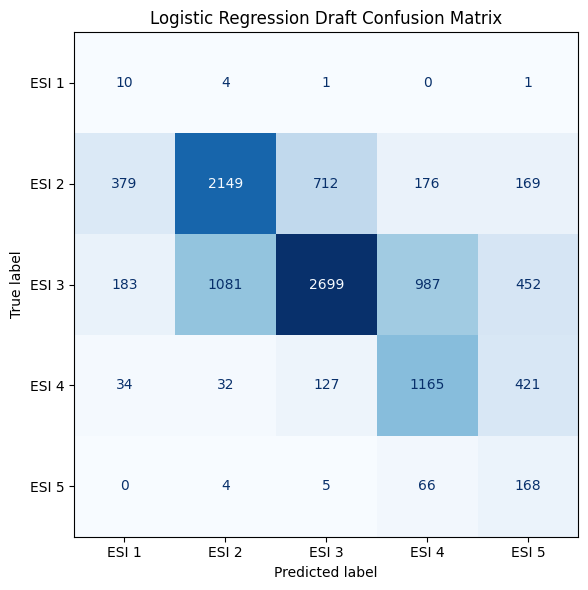

Saved: w6_confusion_logreg.png


In [35]:
# CONFUSION MATRIX: LOGISTIC REGRESSION

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_logreg,
    labels=CLASS_LABELS,
    display_labels=[f"ESI {label}" for label in CLASS_LABELS],
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title("Logistic Regression Draft Confusion Matrix")
plt.tight_layout()
plt.savefig("w6_confusion_logreg.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", "w6_confusion_logreg.png")

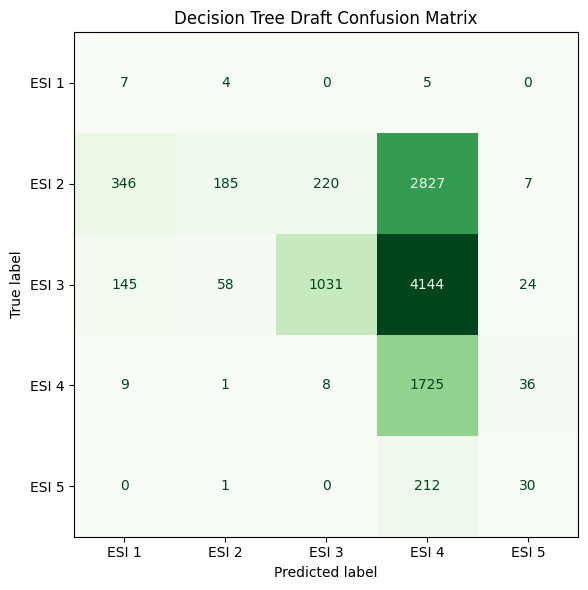

Saved: w6_confusion_tree.png


In [36]:
# CONFUSION MATRIX: DECISION TREE

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_tree,
    labels=CLASS_LABELS,
    display_labels=[f"ESI {label}" for label in CLASS_LABELS],
    cmap="Greens",
    colorbar=False,
    ax=ax,
)
ax.set_title("Decision Tree Draft Confusion Matrix")
plt.tight_layout()
plt.savefig("w6_confusion_tree.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", "w6_confusion_tree.png")

###7. Primary metric choice: recall for ESI 1

**Primary metric for clinical review:** recall for ESI 1.

This asks: among the patients who truly are the most urgent and how many did the model catch?

This matters more than overall accuracy because ESI 1 patients are rare but high risk. A model can look accurate by doing well on common mid-acuity patients while still missing the sickest patients. For triage, the most dangerous failure mode is falsely treating an ESI 1 patient as less urgent, because that could delay immediate care.

In [22]:
# FAILURE MODE SUMMARY FOR ESI 1


# This converts recall into a clinically plain miss rate.

esi1_rows = (y_test == 1).sum()
logreg_esi1_recall = safe_recall_for_label(y_test, pred_logreg, label=1)
tree_esi1_recall = safe_recall_for_label(y_test, pred_tree, label=1)

failure_summary = pd.DataFrame([
    {
        "model": "Logistic regression",
        "ESI1_test_cases": int(esi1_rows),
        "ESI1_recall": round(logreg_esi1_recall, 3),
        "ESI1_miss_rate": round(1 - logreg_esi1_recall, 3),
    },
    {
        "model": "Decision tree",
        "ESI1_test_cases": int(esi1_rows),
        "ESI1_recall": round(tree_esi1_recall, 3),
        "ESI1_miss_rate": round(1 - tree_esi1_recall, 3),
    },
])

failure_summary.to_csv("w6_interim_esi1_failure_summary.csv", index=False)
failure_summary



,model,ESI1_test_cases,ESI1_recall,ESI1_miss_rate
0,Logistic regression,16,0.625,0.375
1,Decision tree,16,0.438,0.562
